In [1]:
import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('cleaned_online_retail.csv')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalSales'] = df['UnitPrice'] * df['Quantity']

In [7]:
hourly_df = df.set_index('InvoiceDate')['TotalSales'].resample('h').sum().reset_index()

In [9]:
ceiling_value = hourly_df['TotalSales'].quantile(0.95)

In [10]:
hourly_df['CappedSales'] = np.where(
    hourly_df['TotalSales'] > ceiling_value, 
    ceiling_value, 
    hourly_df['TotalSales']
)

In [11]:
prophet_df = hourly_df[['InvoiceDate', 'CappedSales']]
prophet_df.columns = ['ds', 'y']

In [14]:
prophet_df.head()

,ds,y
0,2010-12-01 08:00:00,1383.810
1,2010-12-01 09:00:00,4991.066
2,2010-12-01 10:00:00,4991.066
3,2010-12-01 11:00:00,4234.160
4,2010-12-01 12:00:00,4991.066


In [15]:
ml_df = prophet_df[['ds', 'y']].copy()

In [16]:
ml_df.set_index('ds', inplace=True)

In [17]:
ml_df['hour'] = ml_df.index.hour
ml_df['dayofweek'] = ml_df.index.dayofweek
ml_df['month'] = ml_df.index.month
ml_df['is_weekend'] = np.where(ml_df.index.dayofweek >= 5, 1, 0)

In [18]:
ml_df.head()

,y,hour,dayofweek,month,is_weekend
ds,,,,,
2010-12-01 08:00:00,1383.810,8,2,12,0
2010-12-01 09:00:00,4991.066,9,2,12,0
2010-12-01 10:00:00,4991.066,10,2,12,0
2010-12-01 11:00:00,4234.160,11,2,12,0
2010-12-01 12:00:00,4991.066,12,2,12,0


In [ ]:
ml_df['lag_1'] = ml_df['y'].shift(1)       
ml_df['lag_24'] = ml_df['y'].shift(24)     
ml_df['lag_168'] = ml_df['y'].shift(168)

In [20]:
ml_df['rolling_mean_24'] = ml_df['y'].shift(1).rolling(window=24).mean()

In [21]:
ml_df.dropna(inplace=True)

In [22]:
holdout_hours = 168
train_data = ml_df.iloc[:-holdout_hours]
test_data = ml_df.iloc[-holdout_hours:]

In [24]:
ml_df.head()

,y,hour,dayofweek,month,is_weekend,lag_1,lag_24,lag_168,rolling_mean_24
ds,,,,,,,,,
2010-12-08 08:00:00,539.450,8,2,12,0,0.000,0.00,1383.810,1296.585917
2010-12-08 09:00:00,2628.540,9,2,12,0,539.450,4865.96,4991.066,1319.063000
2010-12-08 10:00:00,4991.066,10,2,12,0,2628.540,3880.05,4991.066,1225.837167
2010-12-08 11:00:00,1997.950,11,2,12,0,4991.066,4595.98,4234.160,1272.129500
2010-12-08 12:00:00,4991.066,12,2,12,0,1997.950,2434.69,4991.066,1163.878250


In [25]:
X_train = train_data.drop('y', axis=1)
y_train = train_data['y']
X_test = test_data.drop('y', axis=1)
y_test = test_data['y']

In [47]:
model_xgb = xgb.XGBRegressor(
    n_estimators=1000, 
    learning_rate=0.05, 
    early_stopping_rounds=50,
    eval_metric="rmse"
)

In [48]:
model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [49]:
predictions_xgb = model_xgb.predict(X_test)

In [50]:
mae_xgb = mean_absolute_error(y_test, predictions_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, predictions_xgb))

In [51]:
print("\n--- XGBoost Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae_xgb:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb:.2f}")


--- XGBoost Model Evaluation ---
Mean Absolute Error (MAE): 398.41
Root Mean Squared Error (RMSE): 807.95


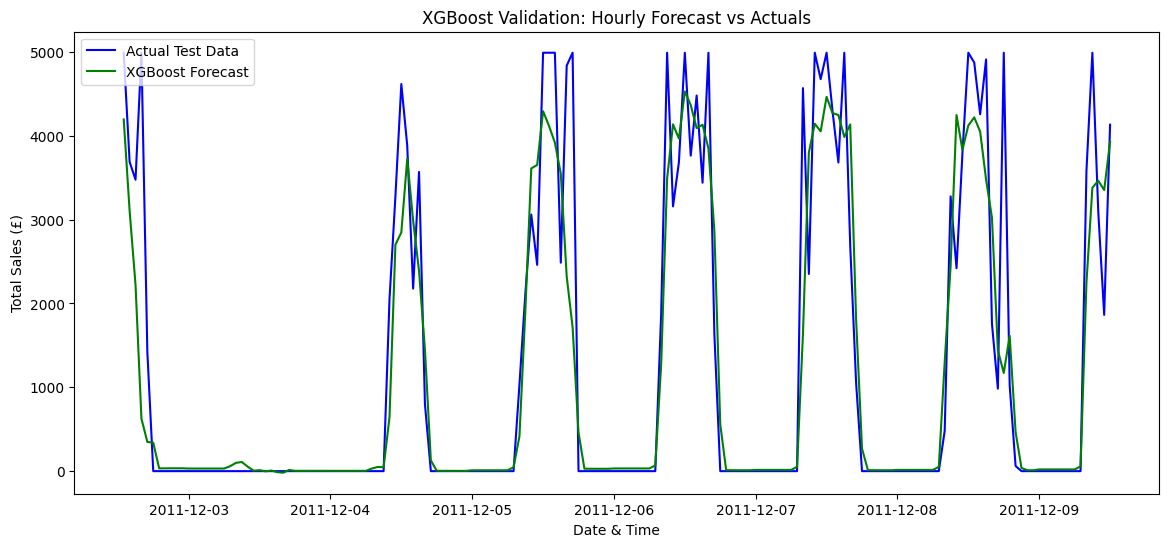

In [52]:
plt.figure(figsize=(14, 6))
plt.plot(test_data.index, y_test, label='Actual Test Data', color='blue')
plt.plot(test_data.index, predictions_xgb, label='XGBoost Forecast', color='green')
plt.title("XGBoost Validation: Hourly Forecast vs Actuals")
plt.xlabel("Date & Time")
plt.ylabel("Total Sales (£)")
plt.legend()
plt.show()

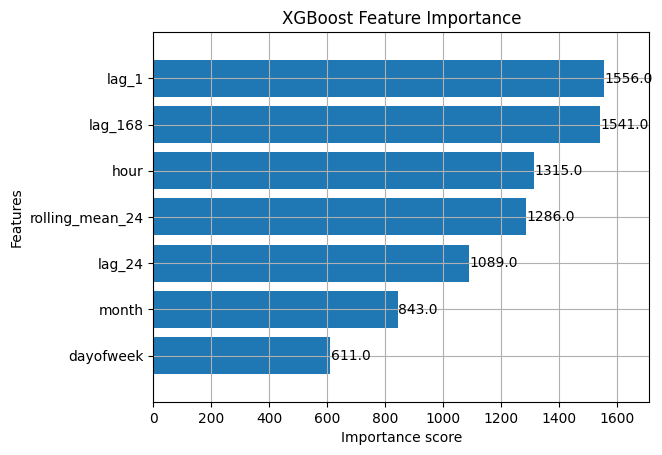

In [53]:
xgb.plot_importance(model_xgb, height=0.8, max_num_features=10)
plt.title("XGBoost Feature Importance")
plt.show()